<div align="center">

# <span style="color: #3498db;">CA2 - MiniMax (Game) Algorithm</span>

**<span style="color:rgb(247, 169, 0);">[Student Name]</span> - <span style="color:rgb(143, 95, 195);">[Student Number]</span>**

</div>

# <span style="color: #3498db;">Checkers with Minimax Algorithm</span>

In this assignment, your tasks are as follows:

- Use a **pre-built Checkers game engine** (board, pieces, valid-move generation) and complete the TODOS we have put.
- Implement the **Minimax search algorithm**.
- Extend Minimax with **Alpha–Beta pruning**.
- And also, experiment with the **evaluation function** to fine tune the AI's playing style to make it as good as possible. (different heuristics)

In [1]:
import time
import pygame
import matplotlib.pyplot as plt

from copy import deepcopy

RED = (255,0,0)
WHITE = (255, 255, 255)

FPS = 60

pygame 2.6.1 (SDL 2.28.4, Python 3.9.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


# <span style="color: #126ca8; font-size:32px;">Actual Game Implementation</span>

In [2]:
# MAKE SURE TO ALSO COMPLETE THE TODO PARTS IN THE GAME IMPLEMENTATION SECTION.

WIDTH, HEIGHT = 800, 800
ROWS, COLS = 8, 8
SQUARE_SIZE = WIDTH//COLS

# rgb
RED = (255, 0, 0)
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
BLUE = (0, 0, 255)
GREY = (128,128,128)

CROWN = pygame.transform.scale(pygame.image.load('assets/crown.png'), (44, 25))

FPS = 60

WIN = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption('Checkers')

In [3]:
def get_row_col_from_mouse(pos):
    x, y = pos
    row = y // SQUARE_SIZE
    col = x // SQUARE_SIZE
    return row, col

In [4]:
class Piece:
    PADDING = 15
    OUTLINE = 2

    def __init__(self, row, col, color):
        self.row = row
        self.col = col
        self.color = color
        self.king = False
        self.x = 0
        self.y = 0
        self.calc_pos()

    def calc_pos(self):
        self.x = SQUARE_SIZE * self.col + SQUARE_SIZE // 2
        self.y = SQUARE_SIZE * self.row + SQUARE_SIZE // 2

    def make_king(self):
        self.king = True

    def draw(self, win):
        radius = SQUARE_SIZE//2 - self.PADDING
        pygame.draw.circle(win, GREY, (self.x, self.y), radius + self.OUTLINE)
        pygame.draw.circle(win, self.color, (self.x, self.y), radius)
        if self.king:
            win.blit(CROWN, (self.x - CROWN.get_width()//2, self.y - CROWN.get_height()//2))

    def move(self, row, col):
        self.row = row
        self.col = col
        self.calc_pos()

    def __repr__(self):
        return str(self.color)

In [5]:
class Board:
    def __init__(self):
        self.board = []
        self.red_left = self.white_left = 12
        self.red_kings = self.white_kings = 0
        self.create_board()

    def draw_squares(self, win):
        win.fill(BLACK)
        for row in range(ROWS):
            for col in range(row % 2, COLS, 2):
                pygame.draw.rect(win, RED, (row*SQUARE_SIZE, col *SQUARE_SIZE, SQUARE_SIZE, SQUARE_SIZE))

    def evaluate(self):
        """
        TODO:
        Evaluation from WHITE's perspective:
        > 0  => White is better
        < 0  => Red is better
        ~ 0  => Equal
        Students must experiment with different hueristics to improve the evaluation function.
        """
        white_score = self.white_left + self.white_kings
        red_score= self.red_left + self.red_kings
        white_final_score = white_score - red_score
        return white_final_score

    def get_all_pieces(self, color):
        pieces = []
        for row in self.board:
            for piece in row:
                if piece != 0 and piece.color == color:
                    pieces.append(piece)
        return pieces

    def move(self, piece, row, col):
        self.board[piece.row][piece.col], self.board[row][col] = self.board[row][col], self.board[piece.row][piece.col]
        piece.move(row, col)

        if row == ROWS - 1 or row == 0:
            piece.make_king()
            if piece.color == WHITE:
                self.white_kings += 1
            else:
                self.red_kings += 1 

    def get_piece(self, row, col):
        return self.board[row][col]

    def create_board(self):
        for row in range(ROWS):
            self.board.append([])
            for col in range(COLS):
                if col % 2 == ((row +  1) % 2):
                    if row < 3:
                        self.board[row].append(Piece(row, col, WHITE))
                    elif row > 4:
                        self.board[row].append(Piece(row, col, RED))
                    else:
                        self.board[row].append(0)
                else:
                    self.board[row].append(0)

    def draw(self, win):
        self.draw_squares(win)
        for row in range(ROWS):
            for col in range(COLS):
                piece = self.board[row][col]
                if piece != 0:
                    piece.draw(win)

    def remove(self, pieces):
        for piece in pieces:
            if piece:
                self.board[piece.row][piece.col] = 0

                if piece.color == RED:
                    self.red_left -= 1
                    if piece.king:
                        self.red_kings -= 1
                else:
                    self.white_left -= 1
                    if piece.king:
                        self.white_kings -= 1

    def winner(self):
        if self.red_left <= 0:
            return WHITE
        if self.white_left <= 0:
            return RED
        return None

    def get_valid_moves(self, piece):
        """
        Get all valid moves for a given piece as:
        { (row, col): [list of captured pieces] }.
        """
        moves = {}
        left = piece.col - 1
        right = piece.col + 1
        row = piece.row

        if piece.color == RED or piece.king:
            moves.update(self._traverse_left(row -1, max(row-3, -1), -1, piece.color, left))
            moves.update(self._traverse_right(row -1, max(row-3, -1), -1, piece.color, right))
        if piece.color == WHITE or piece.king:
            moves.update(self._traverse_left(row +1, min(row+3, ROWS), 1, piece.color, left))
            moves.update(self._traverse_right(row +1, min(row+3, ROWS), 1, piece.color, right))

        return moves

    def _traverse_left(self, start, stop, step, color, left, skipped=[]):
        moves = {}
        last = []
        for r in range(start, stop, step):
            if left < 0:
                break

            current = self.board[r][left]
            if current == 0:
                if skipped and not last:
                    break
                elif skipped:
                    moves[(r, left)] = last + skipped
                else:
                    moves[(r, left)] = last

                if last:
                    if step == -1:
                        row = max(r-3, 0)
                    else:
                        row = min(r+3, ROWS)
                    moves.update(self._traverse_left(r+step, row, step, color, left-1,skipped=last))
                    moves.update(self._traverse_right(r+step, row, step, color, left+1,skipped=last))
                break
            elif current.color == color:
                break
            else:
                last = [current]

            left -= 1

        return moves

    def _traverse_right(self, start, stop, step, color, right, skipped=[]):
        moves = {}
        last = []
        for r in range(start, stop, step):
            if right >= COLS:
                break

            current = self.board[r][right]
            if current == 0:
                if skipped and not last:
                    break
                elif skipped:
                    moves[(r,right)] = last + skipped
                else:
                    moves[(r, right)] = last

                if last:
                    if step == -1:
                        row = max(r-3, 0)
                    else:
                        row = min(r+3, ROWS)
                    moves.update(self._traverse_left(r+step, row, step, color, right-1,skipped=last))
                    moves.update(self._traverse_right(r+step, row, step, color, right+1,skipped=last))
                break
            elif current.color == color:
                break
            else:
                last = [current]

            right += 1

        return moves

In [6]:
class Game:
    def __init__(self, win):
        self._init()
        self.win = win

    def update(self):
        self.board.draw(self.win)
        self.draw_valid_moves(self.valid_moves)
        pygame.display.update()

    def _init(self):
        self.selected = None
        self.board = Board()
        self.turn = RED
        self.valid_moves = {}

    def winner(self):
        piece_winner = self.board.winner()
        if piece_winner is not None:
            return piece_winner

        moves = 0
        for p in self.board.get_all_pieces(self.turn):
            moves += len(self.board.get_valid_moves(p))

        if moves == 0:
            return WHITE if self.turn == RED else RED

        return None

    def reset(self):
        self._init()

    def select(self, row, col):
        if self.selected:
            result = self._move(row, col)
            if not result:
                self.selected = None
                self.select(row, col)

        piece = self.board.get_piece(row, col)
        if piece != 0 and piece.color == self.turn:
            self.selected = piece
            self.valid_moves = self.board.get_valid_moves(piece)
            return True

        return False

    def _move(self, row, col):
        piece = self.board.get_piece(row, col)
        if self.selected and piece == 0 and (row, col) in self.valid_moves:
            self.board.move(self.selected, row, col)
            skipped = self.valid_moves[(row, col)]
            if skipped:
                self.board.remove(skipped)
            self.change_turn()
        else:
            return False

        return True

    def draw_valid_moves(self, moves):
        for move in moves:
            row, col = move
            pygame.draw.circle(self.win, BLUE, (col * SQUARE_SIZE + SQUARE_SIZE//2, row * SQUARE_SIZE + SQUARE_SIZE//2), 15)

    def change_turn(self):
        self.valid_moves = {}
        if self.turn == RED:
            self.turn = WHITE
        else:
            self.turn = RED

    def get_board(self):
        return self.board

    def ai_move(self, board):
        self.board = board
        self.change_turn()

# <span style="color: #126ca8; font-size:32px;">Minimax AI Implementation</span>

In [7]:
# YOU MUST COMPLETE THE MINIMAX SECTION FULLY AND ALSO MAKE SURE TO IMPLEMENT ALPHA BETA PRUNING IN THE OPTIMIZED SECTION

# GIVEN HELPER FUNCTIONS FOR YOUR TO USE IN YOUR MINIMAX IMPLIMENTATION

def simulate_move(piece, move, board, skip):
    """
    Simulate moving 'piece' to 'move' on a cloned board, including captures.
    This is used by the search to explore future positions.
    """
    board.move(piece, move[0], move[1])
    if skip:
        board.remove(skip)

    return board


def get_all_moves(board, color):
    """
    Generate all possible next board positions for 'color'.
    """
    moves = []

    for piece in board.get_all_pieces(color):
        valid_moves = board.get_valid_moves(piece)
        for move, skip in valid_moves.items():
            temp_board = deepcopy(board)
            temp_piece = temp_board.get_piece(piece.row, piece.col)
            new_board = simulate_move(temp_piece, move, temp_board, skip)
            moves.append(new_board)

    return moves

# <span style="color: #126ca8; font-size:32px;">Base (No Alpha/Beta Pruning)</span>

In [8]:
# ================================
# TODO: Implement Plain Minimax
# ================================
# Requirements:
# - max_player: True => WHITE is the maximizing player
# - max_player: False => RED is the minimizing player
# - Use Board.evaluate() as the heuristic evaluation function.
# - Use get_all_moves(board, color) to get next positions.

def minimax(position, depth, max_player: bool):
    # TODO: Implement the base case.
    if(depth == 0 or position.winner() is not None) :
        return position.evaluate(), position

    if max_player:
        max_white_evaluation = float("-inf")
        best_move = None
        for move in get_all_moves(position , WHITE ) :
            evaluate_white_score = minimax(position=move, depth=depth -1 , max_player=False)[0]
            if (evaluate_white_score > max_white_evaluation ):
                max_white_evaluation = evaluate_white_score
                best_move = move
        return max_white_evaluation , best_move
        # TODO: Implement the maximizing branch (WHITE).
        
    else:
        minimum_evaluation = float("inf")
        best_move = None
        for move in get_all_moves(position , RED):
            evaluate_white_score = minimax(position=move , depth=depth-1 , max_player=True)[0]
            if(evaluate_white_score < minimum_evaluation) :
                minimum_evaluation = evaluate_white_score
                best_move = move
        return minimum_evaluation , best_move
            
        # TODO: Implement the minimizing branch (RED).
        

# <span style="color: #126ca8; font-size:32px;">Optimized Version (With Alpha/Beta Pruning)</span>

In [9]:
# ======================================
# TODO: Minimax with Alpha-Beta Pruning
# ======================================
# Implement minimax_alpha_beta with:
# - Same behavior as minimax, but with pruning using (alpha, beta).
# - alpha: best value that the maximizer currently can guarantee.
# - beta : best value that the minimizer currently can guarantee.
# - Prune (break early) as seen in your course materials.


def minimax_alpha_beta(position, depth, alpha, beta, max_player: bool):
    # TODO: Base case (same as plain minimax)

    if (depth == 0 or position.winner() is not None) :
         return position.evaluate() , position
     
    if max_player:
        maximum_evaluation_white = float("-inf")
        best_move = None
        for move in get_all_moves(position , WHITE) : 
            white_evaluation_score = minimax_alpha_beta(position=move , depth=depth-1, alpha=alpha , beta=beta , max_player=False)[0]
            if(white_evaluation_score > maximum_evaluation_white):
                maximum_evaluation_white = white_evaluation_score
                best_move = move
            
            alpha = max(alpha , maximum_evaluation_white)
            if beta <= alpha :
                break
        return maximum_evaluation_white , best_move
                
        # TODO: Maximizing player (WHITE) with alpha-beta.
    else:
        # TODO: Minimizing player (RED) with alpha-beta.
        minimum_evaluation = float("inf")
        best_move = None
        for move in get_all_moves(position , RED) :
            evaluation_score = minimax_alpha_beta(position=move , depth=depth-1 , alpha=alpha , beta=beta , max_player=True)[0]
            if(evaluation_score < minimum_evaluation) :
                minimum_evaluation = evaluation_score
                best_move = move
            beta = min(beta, minimum_evaluation)
            if beta <=alpha :
                break
        return minimum_evaluation , best_move

Running 2 games at Depth 1 (Pruning: False)...
--- Depth: 1 | Without Pruning (Standard Minimax) ---
Total time for 2 games: 0.46 seconds
Average time per game: 0.23 seconds
Average moves per game: 150.0
Results -> WHITE wins: 0, RED wins: 0, Draws: 2
--------------------------------------------------
Running 2 games at Depth 1 (Pruning: True)...
--- Depth: 1 | With Alpha-Beta Pruning ---
Total time for 2 games: 0.44 seconds
Average time per game: 0.22 seconds
Average moves per game: 150.0
Results -> WHITE wins: 0, RED wins: 0, Draws: 2
--------------------------------------------------
Running 2 games at Depth 2 (Pruning: False)...
--- Depth: 2 | Without Pruning (Standard Minimax) ---
Total time for 2 games: 1.96 seconds
Average time per game: 0.98 seconds
Average moves per game: 150.0
Results -> WHITE wins: 0, RED wins: 0, Draws: 2
--------------------------------------------------
Running 2 games at Depth 2 (Pruning: True)...
--- Depth: 2 | With Alpha-Beta Pruning ---
Total time for

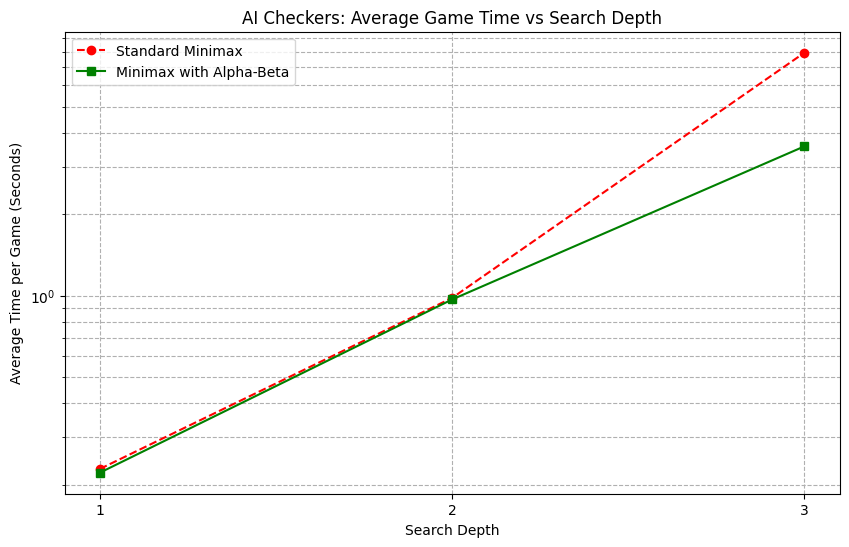

In [10]:
# In this section you should check how your minimax with and without alpha-beta pruning function works.
# You can use the provided checkers game function below also you can also do plots to better show the results.

import time

def play_ai_vs_ai(search_depth=4, use_pruning=True, track_nodes=False, max_moves=150): # اضافه شدن پارامتر max_moves
    """
    Plays a full Checkers game: WHITE AI vs RED AI.
    If the game exceeds max_moves, it ends in a draw.
    """
    # board = Board() # فرض می‌کنیم کلاس Board در کد شما ایمپورت/تعریف شده است
    board = Board()
    turn = RED  
    moves_count = 0

    if track_nodes:
        global NODES_SEEN
        NODES_SEEN = 0

    start_time = time.time()

    while True:
        # ---- [تغییر جدید: شرط خروج برای جلوگیری از حلقه بی‌نهایت] ----
        if moves_count >= max_moves:
            elapsed = time.time() - start_time
            # برگرداندن None به معنی مساوی شدن بازی است
            return None, moves_count, elapsed 
        # -----------------------------------------------------------------

        winner = board.winner()
        if winner is not None:
            elapsed = time.time() - start_time
            return winner, moves_count, elapsed

        all_moves = get_all_moves(board, turn)
        if not all_moves:
            elapsed = time.time() - start_time
            winner = WHITE if turn == RED else RED
            return winner, moves_count, elapsed

        if use_pruning:
            _, best_board = minimax_alpha_beta(
                position=board,
                depth=search_depth,
                alpha=float('-inf'),
                beta=float('inf'),
                max_player=(turn == WHITE)
            )
        else:
            _, best_board = minimax(
                position=board,
                depth=search_depth,
                max_player=(turn == WHITE)
            )

        if best_board is None:
            best_board = all_moves[0]

        board = best_board
        moves_count += 1

        turn = WHITE if turn == RED else RED


# Use the above to complete these to show that your AI can play the game correctly and efficiently.
# You should be able to see that your AI makes good moves.

def print_checkers_results(results, depth, pruning, total_time, avg_moves):
    pruning_str = "With Alpha-Beta Pruning" if pruning else "Without Pruning (Standard Minimax)"
    print(f"--- Depth: {depth} | {pruning_str} ---")
    
    # شمارش برنده‌ها
    white_wins = sum(1 for res in results if res[0] == WHITE)
    red_wins = sum(1 for res in results if res[0] == RED)
    draws = len(results) - (white_wins + red_wins)
    
    print(f"Total time for {len(results)} games: {total_time:.2f} seconds")
    print(f"Average time per game: {total_time / len(results):.2f} seconds")
    print(f"Average moves per game: {avg_moves:.1f}")
    print(f"Results -> WHITE wins: {white_wins}, RED wins: {red_wins}, Draws: {draws}")
    print("-" * 50)

def check_checkers_results(max_depth=3, games_per_setting=5):
    results_data = []
    
    # تست عمق‌های مختلف
    for depth in range(1, max_depth + 1):
        # تست با هرس و بدون هرس
        for use_pruning in [False, True]:
            print(f"Running {games_per_setting} games at Depth {depth} (Pruning: {use_pruning})...")
            
            results = []
            total_time = 0
            total_moves = 0
            
            for _ in range(games_per_setting):
                winner, moves, elapsed = play_ai_vs_ai(search_depth=depth, use_pruning=use_pruning)
                results.append((winner, moves, elapsed))
                total_time += elapsed
                total_moves += moves
                
            avg_moves = total_moves / games_per_setting
            
            # چاپ گزارش این مرحله
            print_checkers_results(results, depth, use_pruning, total_time, avg_moves)
            
            # ذخیره داده‌ها برای رسم نمودار
            results_data.append({
                'depth': depth,
                'pruning': use_pruning,
                'avg_time': total_time / games_per_setting,
                'avg_moves': avg_moves
            })
            
    return results_data


import matplotlib.pyplot as plt

def run_analysis_for_plots(max_depth=4, games_per_setting=3):
    # دریافت داده‌های آزمایش (در عمق‌های بالاتر تعداد بازی را کمتر در نظر می‌گیریم تا خیلی طول نکشد)
    data = check_checkers_results(max_depth, games_per_setting)
    
    depths = list(range(1, max_depth + 1))
    
    # جداسازی زمان‌ها برای دو حالت
    times_no_pruning = [d['avg_time'] for d in data if not d['pruning']]
    times_pruning = [d['avg_time'] for d in data if d['pruning']]
    
    # رسم نمودار زمان بر حسب عمق
    plt.figure(figsize=(10, 6))
    plt.plot(depths, times_no_pruning, marker='o', linestyle='--', color='red', label='Standard Minimax')
    plt.plot(depths, times_pruning, marker='s', linestyle='-', color='green', label='Minimax with Alpha-Beta')
    
    plt.title('AI Checkers: Average Game Time vs Search Depth')
    plt.xlabel('Search Depth')
    plt.ylabel('Average Time per Game (Seconds)')
    plt.xticks(depths)
    plt.yscale('log') # مقیاس لگاریتمی چون زمان به صورت نمایی رشد می‌کند
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

# برای اجرای تست و دیدن نمودار، این خط را اجرا کنید:
run_analysis_for_plots(max_depth=3, games_per_setting=2)


# <span style="color: #126ca8; font-size:32px;">Main Game Loop</span>

In [ ]:
run = True
clock = pygame.time.Clock()
game = Game(WIN)

SEARCH_DEPTH = 4  # Experiment with this depth to see how it affects the game's performance and choose what you deem best.

# ALSO MAKE SURE TO HAVE A MAIN VERSION WITH ALPHA BETA PRUNING SO WE CAN GRADE YOU BASED ON IT!

while run:
    clock.tick(FPS)

    if game.turn == WHITE:
        # AI plays as WHITE using alpha-beta pruning
        _, new_board = minimax_alpha_beta(
            game.get_board(),
            depth=SEARCH_DEPTH,
            alpha=float('-inf'),
            beta=float('inf'),
            max_player=True
        )
        game.ai_move(new_board)

    if game.winner() is not None:
        print("Winner:", "WHITE" if game.winner() == WHITE else "RED")
        run = False

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            run = False

        if event.type == pygame.MOUSEBUTTONDOWN:
            pos = pygame.mouse.get_pos()
            row, col = get_row_col_from_mouse(pos)
            game.select(row, col)

    game.update()

pygame.quit()

: 

<div dir="ltr" style="text-align: left;">

### Theoretical Questions & Analysis

**1. Evaluation Function in Minimax Implementation**
*   **Current Basis (Material Advantage):** In our implementation, nodes are assigned values based on the difference in piece counts. The formula used is roughly `(White Pieces + White Kings) - (Red Pieces + Red Kings)`. Nodes are evaluated based on which player has more remaining pieces on the board, with Kings inherently acting as stronger pieces since they can move backwards.
*   **Alternative Method (Positional Evaluation):** A more advanced alternative is a *Positional Evaluation Function*. Instead of just counting pieces, this method assigns weights to specific squares on the board. For example, pieces on the edges are safer (cannot be jumped) and receive higher scores, and regular pieces closer to the opponent's back row (closer to becoming a King) are weighted more heavily. 
*   **Comparison:** Our material-based function is computationally extremely fast, allowing deeper tree searches. However, the positional function makes the AI play more strategically and positionally sound, though it slows down the calculation per node.

**2. Node Ordering for Maximum Pruning**
*   **Answer:** Yes, the order of visiting child nodes drastically affects pruning and can be optimized.
*   **Explanation (Move Ordering):** Alpha-Beta pruning is most effective when the *best* moves are evaluated first. If the `Maximizing` player finds a high-scoring move early, the `alpha` value increases quickly, causing subsequent, inferior branches to fail the `beta <= alpha` condition and be pruned immediately.
*   **Method:** We can implement "Move Ordering" by applying a shallow heuristic before the deep search. For example, sorting the generated valid moves so that *capture moves* (jumps) or moves that create a King are always evaluated before quiet, regular moves. 

**3. Branching Factor and its Changes During the Game**
*   **Definition:** The "Branching Factor" (commonly denoted as *b*) refers to the average number of legal moves available to a player from any given game state.
*   **Progression in Checkers:**
    *   **Opening/Start:** The branching factor is relatively low (around 7 to 9), as pieces are blocked by their own teammates.
    *   **Mid-game:** As pieces advance and the board opens up, the branching factor peaks. The introduction of Kings and multi-jump capture sequences can temporarily push the branching factor much higher (often 10-12+).
    *   **Endgame:** As the board empties and fewer pieces remain, the number of legal moves drops significantly, leading to a very small branching factor.

**4. Why Pruning Does Not Decrease Accuracy**
*   **Explanation:** Alpha-Beta pruning does not lose accuracy because it is an **Exact Algorithm**, not an approximation. It only discards branches that are mathematically guaranteed to have no impact on the final decision. 
*   **Logic:** If the Maximizer has already found a path guaranteeing a score of +5, and while exploring a new branch, the Minimizer has a move that drops the score to +2, the Maximizer immediately stops exploring that branch. Why? Because a rational Minimizer will *at least* force the score down to +2, making it strictly worse than the +5 already secured. Thus, unsearched nodes in that branch are irrelevant.

**5. Minimax Against a Random Opponent**
*   **The Problem:** Minimax is built on the strict assumption that the opponent plays optimally (always choosing the move that is worst for us). It is highly pessimistic. If the opponent plays randomly, Minimax will still assume the opponent is setting brilliant traps. Consequently, Minimax might play overly defensively and fail to exploit the obvious blunders made by a random player.
*   **Alternative Algorithm:** **Expectiminimax**. 
*   **Explanation:** Expectiminimax replaces the strict `Min` nodes with `Chance` nodes. Instead of assuming the opponent will take the absolute worst path for us, it calculates the *Expected Value* (weighted average) of all possible opponent moves based on their probability. Against a random opponent, all legal moves have an equal probability, allowing Expectiminimax to take calculated risks and actively exploit the opponent's random, sub-optimal play.

</div>
